# Plot the SFS for the LoF variants in high and low selected genes and CES genes

In [1]:
# --- make parent folder importable ---
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))  # points to Paper_SFS/

# --- usual imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm
from scipy.integrate import simpson, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import re
import csv
from tqdm import tqdm
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import json
import LoF_func
import plot_SFS

In [2]:
# Values of parameters to be passed to calculate the Likelihood
LoF_filename  = "../Data/gnomad_lof_full.txt.gz"
outdir_pnull  = "Pnull_values"
pkl_LL_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/"
demography = "NFE"
SFS_file      = f"/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS/SFS_{demography}.pkl"
ac_col, AN_col = LoF_func.choose_ac_an_cols(demography)

df_LoF_orig = pd.read_csv(LoF_filename, sep="\t", compression="gzip")
gene_dfs_full = LoF_func.construct_per_gene_dfs(df_LoF_orig)
# compute gene sizes
gene_size_dict = {gid: len(df) for gid, df in gene_dfs_full.items()}
# Filters out the CES genes and variants with allele counts >5000
CE_genes = np.array(['ENSG00000078369', 'ENSG00000157933', 'ENSG00000198793', 'ENSG00000117713', 'ENSG00000117400', 'ENSG00000213281', 'ENSG00000143379', 'ENSG00000143622',
                     'ENSG00000135829', 'ENSG00000117139', 'ENSG00000171862', 'ENSG00000108055', 'ENSG00000108061', 'ENSG00000148737', 'ENSG00000066468', 'ENSG00000174775',
                     'ENSG00000184937', 'ENSG00000149480', 'ENSG00000168066', 'ENSG00000175115', 'ENSG00000160584', 'ENSG00000110395', 'ENSG00000111262', 'ENSG00000273079',
                     'ENSG00000133703', 'ENSG00000110844', 'ENSG00000111252', 'ENSG00000179295', 'ENSG00000083642', 'ENSG00000136158', 'ENSG00000176165', 'ENSG00000119596',
                     'ENSG00000179364', 'ENSG00000140262', 'ENSG00000169032', 'ENSG00000137834', 'ENSG00000080603', 'ENSG00000102962', 'ENSG00000174231', 'ENSG00000141510',
                     'ENSG00000196712', 'ENSG00000178691', 'ENSG00000136450', 'ENSG00000170836', 'ENSG00000141376', 'ENSG00000087191', 'ENSG00000161547', 'ENSG00000101752',
                     'ENSG00000152217', 'ENSG00000141646', 'ENSG00000134440', 'ENSG00000256463', 'ENSG00000105204', 'ENSG00000263002', 'ENSG00000160007', 'ENSG00000087088',
                     'ENSG00000063244', 'ENSG00000115758', 'ENSG00000119772', 'ENSG00000213639', 'ENSG00000198369', 'ENSG00000136710', 'ENSG00000115524', 'ENSG00000204217',
                     'ENSG00000036257', 'ENSG00000101266', 'ENSG00000171456', 'ENSG00000244462', 'ENSG00000124233', 'ENSG00000156304', 'ENSG00000159216', 'ENSG00000160201',
                     'ENSG00000099949', 'ENSG00000254709', 'ENSG00000183765', 'ENSG00000099995', 'ENSG00000100393', 'ENSG00000172936', 'ENSG00000168036', 'ENSG00000181555',
                     'ENSG00000169855', 'ENSG00000118007', 'ENSG00000155903', 'ENSG00000159692', 'ENSG00000068078', 'ENSG00000168769', 'ENSG00000113163', 'ENSG00000185129',
                     'ENSG00000145907', 'ENSG00000181163', 'ENSG00000165671', 'ENSG00000204469', 'ENSG00000204435', 'ENSG00000112640', 'ENSG00000171467', 'ENSG00000146247',
                     'ENSG00000164494', 'ENSG00000049618', 'ENSG00000065883', 'ENSG00000146830', 'ENSG00000005483', 'ENSG00000064419', 'ENSG00000157764', 'ENSG00000158941',
                     'ENSG00000164754', 'ENSG00000169249', 'ENSG00000215301', 'ENSG00000126752', 'ENSG00000072501', 'ENSG00000177485', 'ENSG00000101972', 'ENSG00000156531', 
                     'ENSG00000165509', 'ENSG00000167548'])

with open("../Data/missense/GG_EVAL/genemap2_dom_not_rec_ENS.txt") as f:
    dom_gene_list = [line.strip() for line in f if line.strip()]
    
df_LoF = df_LoF_orig[~(df_LoF_orig['gene_id'].isin(CE_genes)) & (df_LoF_orig[ac_col]<=5000)].reset_index(drop = True)

# Get LoFs in form a dictionary with LoF dataframe as values and Ensembl gene_id as item keys
gene_dfs = LoF_func.construct_per_gene_dfs(df_LoF)

# Predicted theoretical SFSs for all Roulette values and 500 selection values from (-10**-6 to -100) + neutral (s = 0) for allele counts from 0 to kmax
with open(SFS_file, "rb") as f:
    SFSs = pickle.load(f)
s_values = -np.logspace(np.log10(10**-6), np.log10(100), num=500)  # Grid of selection values. SFSs 2nd index num+1 (grid + neutral) values. Here it is 500+1 values

LL_sum_dict = LoF_func.get_LL_estimates([demography], pkl_LL_folder)

# load pnull dict for this demography once
pnull_dict = pd.read_csv(f"{outdir_pnull}/{demography}.csv", index_col=0)["pnull"].to_dict()

In [ ]:
# Functions to find the SFS from observed allele counts, and to find the predicted SFS for a given gene and demography from the pre-computed SFSs and pnull values
def observed_counts_from_ac(ac, nn_tot, jmin, bb, incl_zero = True):

    nn = np.ones_like(ac, dtype=float)         # each site counts once

    # Construct bins: unit bins up to 4, then geometric
    bins = plot_SFS.make_bins(jmin=jmin, bb=bb, nn=nn_tot, incl_zero = incl_zero)
    # Bin sizes (widths in allele-count units)
    widths = plot_SFS.bin_sizes(bins)
    # Raw totals per bin
    totals = plot_SFS.bin_data(ac, nn, bins)
    # Normalize to density: counts per allele-count unit
    density = totals / widths
    # Get bin midpoints
    means = plot_SFS.bin_means(bins)

    return means, density

def predicted_counts_gene(gene_df, SFSs, s_ind, pnull_dict, kmax=5000):
    """
    Predicted expected counts per exact allele count k, for one demography.
    SFSs shape assumed: (n_mu, n_s_plus_neut, kmax+1) with neutral at index -1.
    """
    pred = np.zeros(kmax+1, dtype=float)

    mu_inds = gene_df["MR_rank"].to_numpy(dtype=int)
    annots  = gene_df["most_severe_consequence2"].astype(str).to_numpy()

    for mu_i, annot in zip(mu_inds, annots):
        pnull = pnull_dict.get(annot, None)
        if pnull is None:
            continue
        pred += pnull * SFSs[mu_i, -1, :kmax+1] + (1 - pnull) * SFSs[mu_i, s_ind, :kmax+1]

    return pred

In [ ]:
# Plot function: single plot overlaying multiple genes with different s_het, showing Observed (points) and Predicted (dashed lines).
# Nature (ggsci::npg) color palette
color_cycle = [
    "#E64B35",  # red
    "#4DBBD5",  # blue
    "#00A087",  # green
    "#3C5488",  # navy
    "#F39B7F",  # orange
    "#8491B4",  # purple
    "#91D1C2",  # teal
    "#DC0000",  # dark red
]

def plot_sfs_multiple_genes_one_demography(gene_ids, gene_dfs, LL_sum_dict, s_values, demography, SFSs_demog, pnull_dict, ac_col, an_col, gene_size_dict, df_summary,
                                       kmax=100, jmin=4, bb=2.0, figsize=(6, 4), dpi = 300,  # good for 1-column-ish paper width; adjust as needed
                                       outfile=None):
    """
    Single plot overlaying multiple genes with different s_hat,
    showing Observed (points) and Predicted (dashed lines).
    """

    # --- pick 4 genes (closest to target s) ---
    chosen = gene_ids

    if len(chosen) == 0:
        raise ValueError("No genes could be chosen (check LL_sum_dict/s_values overlap).")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    gene_handles = []

    for idx, gene_id in enumerate(chosen):
        if gene_id not in gene_dfs or gene_id not in LL_sum_dict:
            continue

        df = gene_dfs[gene_id]
        if df is None or df.empty or ac_col not in df.columns or an_col not in df.columns:
            continue

        ac = df[ac_col].to_numpy()
        AN = df[an_col].mode().iloc[0]

        LL_vec = np.asarray(LL_sum_dict[gene_id], float)
        s_ind = int(np.argmax(LL_vec))
        s_hat = df_summary[df_summary["gene_id"] == gene_id]["Posterior_mean"].values[0]

        # Observed (binned) + Predicted (exact)
        mean_obs, obs_counts = observed_counts_from_ac(ac, AN, jmin, bb)
        pred_counts = predicted_counts_gene(df, SFSs_demog, s_ind, pnull_dict, kmax=kmax)

        total = gene_size_dict[gene_id]

        # ---- DROP k=0 ----
        m = np.asarray(mean_obs)
        obs_y = np.asarray(obs_counts, float) / total
        keep_obs = (m >= 1) & (m <= kmax) & np.isfinite(obs_y) & (obs_y > 0)
        m = m[keep_obs]
        obs_y = obs_y[keep_obs]

        kmax_new = m[-1] +5

        k = np.arange(len(pred_counts))
        pred_y = np.asarray(pred_counts, float) / total
        keep_pred = (k >= 1) & (k <= kmax_new) & np.isfinite(pred_y) & (pred_y > 0)
        k = k[keep_pred]
        pred_y = pred_y[keep_pred]

        c = color_cycle[idx % len(color_cycle)]

        # Observed = points, Predicted = dashed line
        ax.scatter(m, obs_y, s=18, alpha=0.9, edgecolors="none", color=c)
        ax.plot(k, pred_y, lw=2.0, ls="--", color=c)

        gene_handles.append(
            Line2D([0], [0], color=c, lw=2.2, label=rf"$s_{{\mathrm{{het}}}} = {s_hat:.1e}$")
        )

    # Axes styling (paper-friendly)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1-0.1, kmax_new+1)
    ax.set_xlabel("Allele count (k)")
    ax.set_ylabel("Density")

    ticks = [1, 2, 5, 10, 20, 50, 100]
    ticks = [t for t in ticks if t <= kmax_new]
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.ticklabel_format(axis='x', style='plain')

    # Legends: gene colors + obs/pred style
    style_handles = [
        Line2D([0], [0], marker='o', color='k', lw=0, markersize=5, label="Observed"),
        Line2D([0], [0], color='k', lw=2.0, ls='--', label="Predicted"),
    ]

    leg1 = ax.legend(handles=gene_handles, loc="upper right", frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc="lower left", frameon=False)

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight")


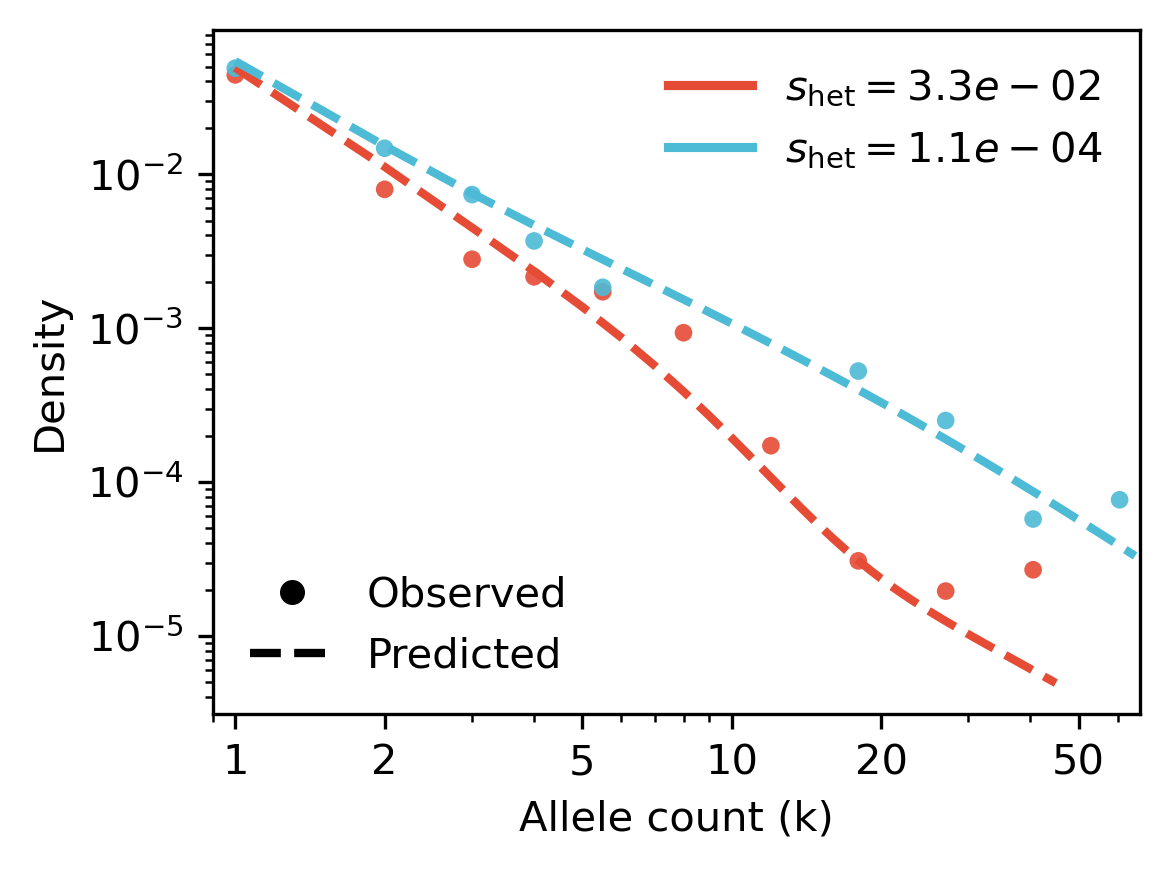

In [ ]:
gene_ids_plot = ['ENSG00000054654','ENSG00000154263']
plot_sfs_multiple_genes_one_demography(gene_ids_plot, gene_dfs, LL_sum_dict, s_values, demography, SFSs, pnull_dict, ac_col, AN_col, gene_size_dict, df_summary,
                                       kmax=100, jmin=4, bb=1.5, figsize=(4, 3),  # good for 1-column-ish paper width; adjust as needed
                                       outfile="../Figures/SFS_sel.svg")

## CES gene

#### Get gene details

In [5]:
# Values of parameters to be passed to calculate the Likelihood
syn_filename  = "../Data/synonymous_data.txt.gz" 

LoF_filename  = "../Data/gnomad_lof_full.txt.gz"
outdir_pnull  = "Pnull_values"
pkl_LL_folder = "/n/data2/hms/dbmi/sunyaev/lab/pkar/likelihood_s_anc/"
demography = "NFE"
SFS_folder     = "/n/data2/hms/dbmi/sunyaev/lab/pkar/demography_SFS"
ac_col, AN_col = LoF_func.choose_ac_an_cols(demography)

# Get the syn and LoF file loaded and get the columns that store allele counts
df_syn_orig = pd.read_csv(syn_filename, sep="\t", compression="gzip")
df_LoF_orig = pd.read_csv(LoF_filename, sep="\t", compression="gzip")

unique_MR = df_syn_orig['MR'].unique()
MR_rank_dict = {value: rank for rank, value in enumerate(sorted(unique_MR))}
# Assign the rank to each row based on 'MR' values
df_syn_orig['MR_rank'] = df_syn_orig['MR'].map(MR_rank_dict)

gene_dfs_full_syn = LoF_func.construct_per_gene_dfs(df_syn_orig)
gene_dfs_full_LoF = LoF_func.construct_per_gene_dfs(df_LoF_orig)
# compute gene sizes
gene_size_dict_syn = {gid: len(df) for gid, df in gene_dfs_full_syn.items()}
gene_size_dict_LoF = {gid: len(df) for gid, df in gene_dfs_full_LoF.items()}

df_syn = df_syn_orig[(df_syn_orig[ac_col]<=50000)].reset_index(drop = True)
df_LoF = df_LoF_orig[(df_LoF_orig[ac_col]<=50000)].reset_index(drop = True)

# Get LoFs in form a dictionary with LoF dataframe as values and Ensembl gene_id as item keys
gene_dfs_syn = LoF_func.construct_per_gene_dfs(df_syn)
gene_dfs_LoF = LoF_func.construct_per_gene_dfs(df_LoF)

kappa = np.logspace(0, 2, num = 50)
s_values = -np.logspace(np.log10(1e-6), np.log10(100), num=100)  # Grid of selection values. SFSs 2nd index num+1 (grid + neutral) values. Here it is 500+1 values

# Predicted theoretical SFSs for all Roulette values and 100 selection values from (-10**-6 to -100) + neutral (s = 0) for allele counts from 0 to kmax
SFS_file = SFS_folder + f"/SFS_{demography}_CES.pkl"
with open(SFS_file, "rb") as f:
    SFSs = pickle.load(f)

LL_sum_dict = LoF_func.get_LL_estimates([demography], pkl_LL_folder, CES = True)

# Find the likelihood of observing LoF SFS as a function of s for all genes and store them
pnull_dict = pd.read_csv(f"{outdir_pnull}/{demography}.csv", index_col=0)["pnull"].to_dict()

In [6]:
def observed_counts_from_ac(ac, nn_tot, jmin, bb, incl_zero = True):

    nn = np.ones_like(ac, dtype=float)         # each site counts once

    # Construct bins: unit bins up to 4, then geometric
    bins = plot_SFS.make_bins(jmin=jmin, bb=bb, nn=nn_tot, incl_zero = incl_zero)
    # Bin sizes (widths in allele-count units)
    widths = plot_SFS.bin_sizes(bins)
    # Raw totals per bin
    totals = plot_SFS.bin_data(ac, nn, bins)
    # Normalize to density: counts per allele-count unit
    density = totals / widths
    # Get bin midpoints
    means = plot_SFS.bin_means(bins)

    return means, density

def predicted_counts_gene(gene_df, SFSs, kappa_ind, s_ind, pnull_dict, syn, kmax=5000):
    """
    Predicted expected counts per exact allele count k, for one demography.
    SFSs shape assumed: (n_mu, n_s_plus_neut, kmax+1) with neutral at index -1.
    """
    pred = np.zeros(kmax+1, dtype=float)

    if syn == True:
        mu_inds = gene_df["MR_rank"].to_numpy(dtype=int)
        for mu_i in mu_inds:
            pred += SFSs[mu_i, 0, -1, :kmax+1]

    else:
        mu_inds = gene_df["MR_rank"].to_numpy(dtype=int)
        annots  = gene_df["most_severe_consequence2"].astype(str).to_numpy()
        for mu_i, annot in zip(mu_inds, annots):
            pnull = pnull_dict.get(annot, None)
            if pnull is None:
                continue
            pred += pnull * SFSs[mu_i, 0, -1, :kmax+1] + (1 - pnull) * SFSs[mu_i, kappa_ind, s_ind, :kmax+1]
    
    return pred

#### Plotting functions

In [ ]:
# Plot the observed SFS for LoF and synonymous variants and the predicted SFS for the best-fit kappa and s values for the same gene, along with the predicted SFS under neutrality and no CES effect
# Nature (ggsci::npg) color palette
color_cycle = [
    "#E64B35",  # red
    "#4DBBD5",  # blue
    "#00A087",  # green
    "#3C5488",  # navy
    "#F39B7F",  # orange
    "#8491B4",  # purple
    "#91D1C2",  # teal
    "#DC0000",  # dark red
]

def plot_sfs_CES_LoF_syn_genes(gene_ids, gene_dfs_LoF, gene_dfs_syn, LL_sum_dict, kappa_values, s_values, demography, SFSs_demog, pnull_dict, 
                               ac_col, an_col, gene_size_dict_LoF, gene_size_dict_syn, kmax=100, jmin=4, bb=2.0, figsize=(6, 4), dpi = 300,  # good for 1-column-ish paper width; adjust as needed
                               outfile=None):
    """
    Single plot overlaying 4 genes with different s_hat (closest to targets),
    showing Observed (points) and Predicted (dashed lines).
    Includes k=0 using a broken x-axis (0..1 linear panel + 1..kmax log panel).
    """

    # --- pick 4 genes (closest to target s) ---
    chosen = gene_ids

    if len(chosen) == 0:
        raise ValueError("No genes could be chosen (check LL_sum_dict/s_values overlap).")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    gene_handles = []

    for idx, gene_id in enumerate(chosen):
        if gene_id not in gene_dfs_LoF or gene_id not in gene_dfs_syn or gene_id not in LL_sum_dict:
            continue

        df_LoF_gene = gene_dfs_LoF[gene_id]
        df_syn_gene = gene_dfs_syn[gene_id]

        ac_LoF = df_LoF_gene[ac_col].to_numpy()
        AN_LoF = df_LoF_gene[an_col].mode().iloc[0]
        ac_syn = df_syn_gene[ac_col].to_numpy()
        AN_syn = df_syn_gene[an_col].mode().iloc[0]

        LL_surface = np.asarray(LL_sum_dict[gene_id], float)
        kappa_idx, s_idx = np.unravel_index(np.argmax(LL_surface), LL_surface.shape)

        # Observed (binned) + Predicted (exact) -syn
        mean_obs_syn, obs_counts_syn = observed_counts_from_ac(ac_syn, AN_syn, jmin, bb)
        pred_counts_syn = predicted_counts_gene(df_syn_gene, SFSs_demog, None, None, pnull_dict, syn = True, kmax=kmax)
        total_syn = gene_size_dict_syn[gene_id]

        # Observed (binned) + Predicted (exact) - LoF
        mean_obs_LoF, obs_counts_LoF = observed_counts_from_ac(ac_LoF, AN_LoF, jmin, bb)
        pred_counts_LoF = predicted_counts_gene(df_LoF_gene, SFSs_demog, kappa_idx, s_idx, pnull_dict, syn = False, kmax=kmax)
        pred_counts_LoF_kappa_s_neutral = predicted_counts_gene(df_LoF_gene, SFSs_demog, 0, -1, pnull_dict, syn = False, kmax=kmax)
        total_LoF = gene_size_dict_LoF[gene_id]

        # ---- LoF ----
        m_LoF = np.asarray(mean_obs_LoF)
        obs_y_LoF = np.asarray(obs_counts_LoF, float) / total_LoF
        keep_obs_LoF = (m_LoF >= 1) & (m_LoF <= kmax) & np.isfinite(obs_y_LoF) & (obs_y_LoF > 0)
        m_LoF = m_LoF[keep_obs_LoF]
        obs_y_LoF = obs_y_LoF[keep_obs_LoF]
        kmax_new_LoF = m_LoF[-1] +50
        k_LoF = np.arange(len(pred_counts_LoF))
        pred_y_LoF = np.asarray(pred_counts_LoF, float) / total_LoF
        pred_y_LoF_kappa_s_neutral = np.asarray(pred_counts_LoF_kappa_s_neutral, float) / total_LoF

        # ---- syn ----
        m_syn = np.asarray(mean_obs_syn)
        obs_y_syn = np.asarray(obs_counts_syn, float) / total_syn
        keep_obs_syn = (m_syn >= 1) & (m_syn <= kmax) & np.isfinite(obs_y_syn) & (obs_y_syn > 0)
        m_syn = m_syn[keep_obs_syn]
        obs_y_syn = obs_y_syn[keep_obs_syn]
        kmax_new_syn = m_syn[-1] +5
        k_syn = np.arange(len(pred_counts_syn))
        pred_y_syn = np.asarray(pred_counts_syn, float) / total_syn

        # ---- Predicted ----        
        keep_pred_LoF = (k_LoF >= 1) & (k_LoF <= kmax_new_LoF) & np.isfinite(pred_y_LoF) & (pred_y_LoF > 0)
        keep_pred_LoF_kappa_s_neutral = (k_LoF >= 1) & (k_LoF <= kmax_new_LoF) & np.isfinite(pred_y_LoF_kappa_s_neutral) & (pred_y_LoF_kappa_s_neutral > 0)
        k_LoF = k_LoF[keep_pred_LoF]
        pred_y_LoF = pred_y_LoF[keep_pred_LoF]
        pred_y_LoF_kappa_s_neutral = pred_y_LoF_kappa_s_neutral[keep_pred_LoF_kappa_s_neutral]
        c = color_cycle[(idx+2) % len(color_cycle)]
        # Observed = points, Predicted = dashed line
        ax.scatter(m_LoF, obs_y_LoF, s=18, alpha=0.9, edgecolors="none", color=c)
        ax.plot(k_LoF, pred_y_LoF, lw=2.0, ls="--", color=c)
        ax.plot(k_LoF, pred_y_LoF_kappa_s_neutral, lw=2.0, ls=":", color=c)
        gene_handles.append(
            Line2D([0], [0], color=c, lw=2.2, label="Loss-of-function")
        )

        keep_pred_syn = (k_syn >= 1) & (k_syn <= kmax_new_syn) & np.isfinite(pred_y_syn) & (pred_y_syn > 0)
        k_syn = k_syn[keep_pred_syn]
        pred_y_syn = pred_y_syn[keep_pred_syn]
        c = color_cycle[(idx+3) % len(color_cycle)]
        # Observed = points, Predicted = dashed line
        ax.scatter(m_syn, obs_y_syn, s=18, alpha=0.9, edgecolors="none", color=c)
        ax.plot(k_syn, pred_y_syn, lw=2.0, ls=":", color=c)
        gene_handles.append(
            Line2D([0], [0], color=c, lw=2.2, label="Synonymous")
        )

    # Axes styling (paper-friendly)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1-0.1, max(kmax_new_syn, kmax_new_LoF)+1)
    ax.set_xlabel("Allele count (k)")
    ax.set_ylabel("Density")

    ticks = [1, 2, 5, 10, 20, 50, 100, 300]
    ticks = [t for t in ticks if t <= max(kmax_new_syn, kmax_new_LoF)]
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.ticklabel_format(axis='x', style='plain')

    # Legends: gene colors + obs/pred style
    style_handles = [
        Line2D([0], [0], marker='o', color='k', lw=0, markersize=5, label="Observed"),
        Line2D([0], [0], color='k', lw=2.0, ls=':', label=r"Predicted ($\kappa$ = 1, $s_{het}$ = 0)"),
        Line2D([0], [0], color='k', lw=2.0, ls='--', label=rf"Predicted ($\kappa$ = {kappa_values[kappa_idx]:.1f}, $s_{{het}}$ = {s_values[s_idx]:.2f})")
    ]

    leg1 = ax.legend(handles=gene_handles, loc="upper right", frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc="lower left", frameon=False)

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight")


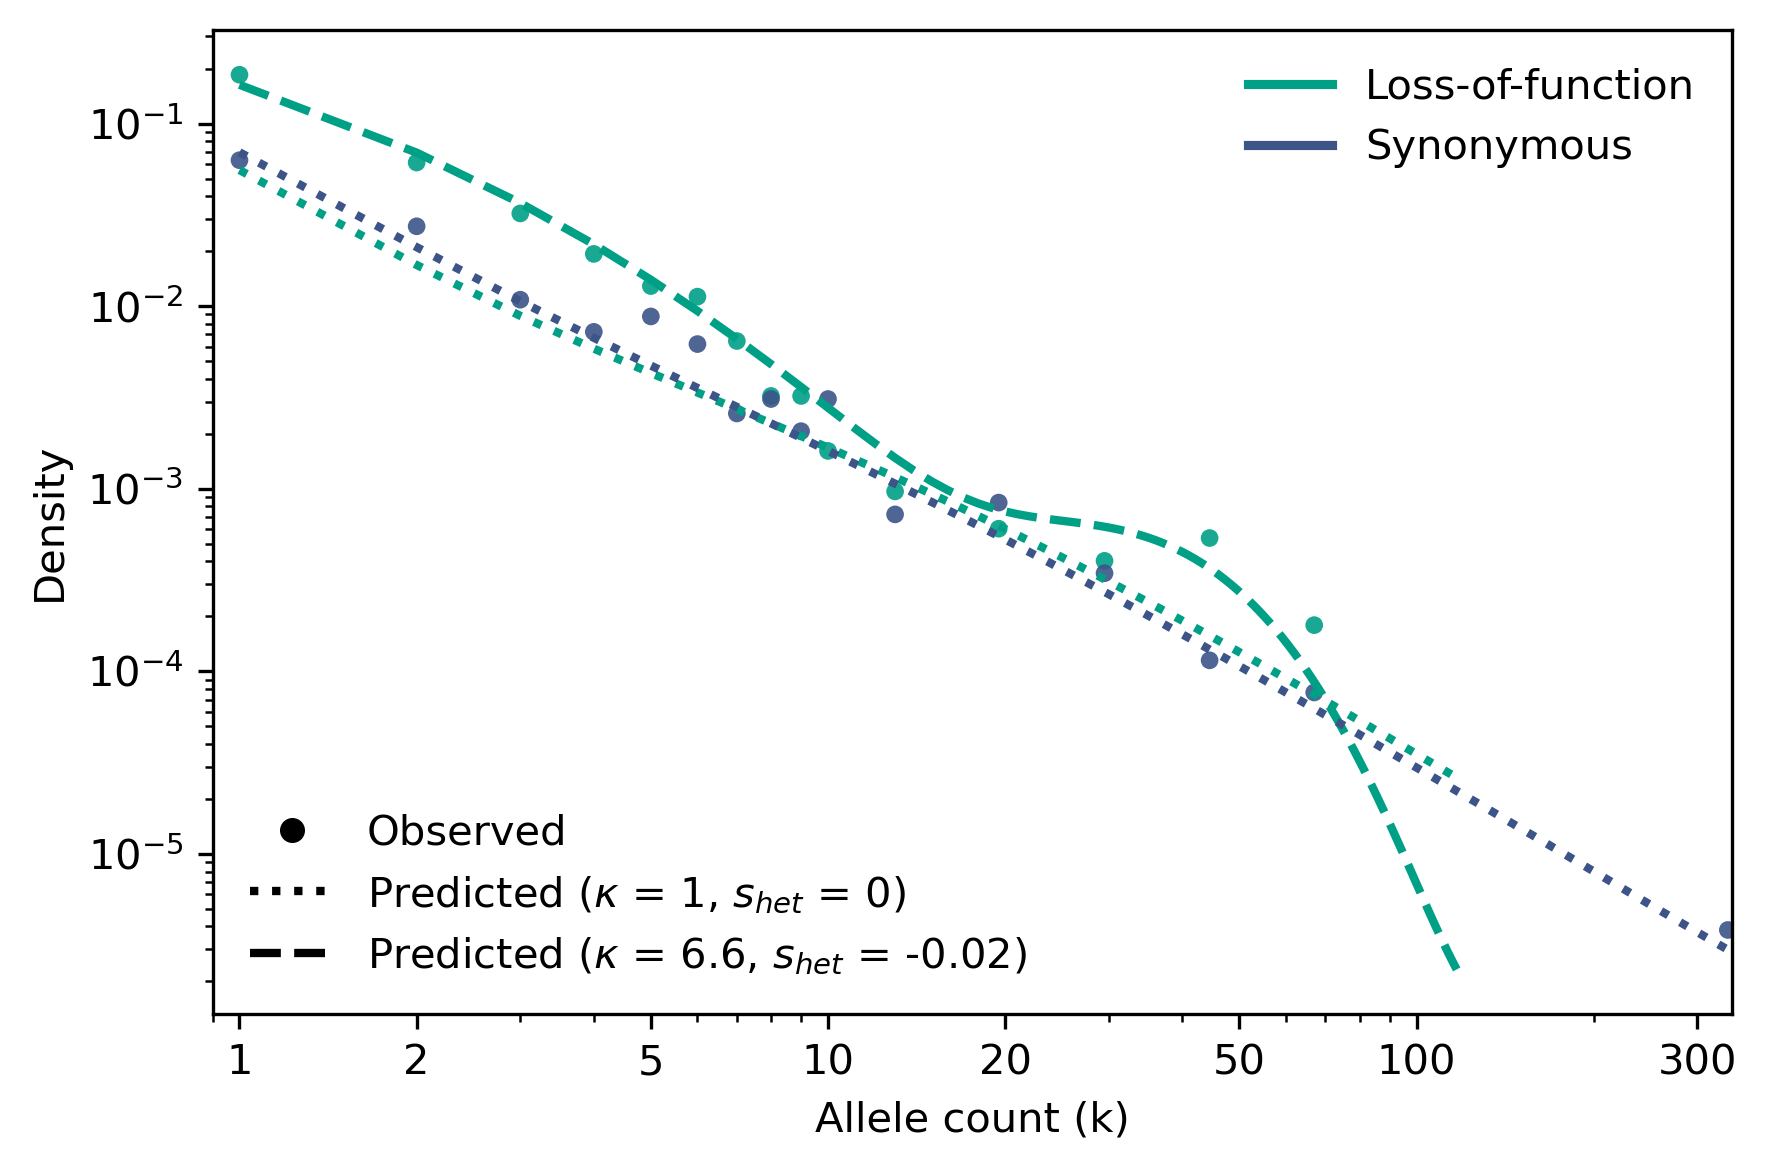

In [32]:
gene_ids_plot = ["ENSG00000101752"]
plot_sfs_CES_LoF_syn_genes(gene_ids_plot, gene_dfs_LoF, gene_dfs_syn, LL_sum_dict, kappa, s_values, demography, SFSs, pnull_dict, 
                               ac_col, AN_col, gene_size_dict_LoF, gene_size_dict_syn, kmax=400, jmin=10, bb=1.5, figsize=(6, 4), dpi = 300, outfile="../Figures/SFS_MIB1.svg")

In [ ]:
# Plot the observed SFS for LoF variants and the predicted SFS for the best-fit kappa and s values for the same gene, along with the predicted SFS under neutrality and under the best-fit kappa but neutral s, to show how the observed SFS compares to these different predictions.
# Nature (ggsci::npg) color palette
color_cycle = [
    "#E64B35",  # red
    "#4DBBD5",  # blue
    "#00A087",  # green
    "#3C5488",  # navy
    "#F39B7F",  # orange
    "#8491B4",  # purple
    "#91D1C2",  # teal
    "#DC0000",  # dark red
]

def plot_sfs_CES_LoF_syn_genes(gene_ids, gene_dfs_LoF, gene_dfs_syn, LL_sum_dict, kappa_values, s_values, demography, SFSs_demog, pnull_dict, 
                               ac_col, an_col, gene_size_dict_LoF, gene_size_dict_syn, kmax=100, jmin=4, bb=2.0, figsize=(6, 4), dpi = 300,  # good for 1-column-ish paper width; adjust as needed
                               outfile=None):
    """
    Single plot overlaying 4 genes with different s_hat (closest to targets),
    showing Observed (points) and Predicted (dashed lines).
    Includes k=0 using a broken x-axis (0..1 linear panel + 1..kmax log panel).
    """

    # --- pick 4 genes (closest to target s) ---
    chosen = gene_ids

    if len(chosen) == 0:
        raise ValueError("No genes could be chosen (check LL_sum_dict/s_values overlap).")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    gene_handles = []

    for idx, gene_id in enumerate(chosen):
        if gene_id not in gene_dfs_LoF or gene_id not in gene_dfs_syn or gene_id not in LL_sum_dict:
            continue

        df_LoF_gene = gene_dfs_LoF[gene_id]
        df_syn_gene = gene_dfs_syn[gene_id]

        ac_LoF = df_LoF_gene[ac_col].to_numpy()
        AN_LoF = df_LoF_gene[an_col].mode().iloc[0]
        ac_syn = df_syn_gene[ac_col].to_numpy()
        AN_syn = df_syn_gene[an_col].mode().iloc[0]

        LL_surface = np.asarray(LL_sum_dict[gene_id], float)
        kappa_idx, s_idx = np.unravel_index(np.argmax(LL_surface), LL_surface.shape)

        # Observed (binned) + Predicted (exact) -syn
        mean_obs_syn, obs_counts_syn = observed_counts_from_ac(ac_syn, AN_syn, jmin, bb)
        pred_counts_syn = predicted_counts_gene(df_syn_gene, SFSs_demog, None, None, pnull_dict, syn = True, kmax=kmax)
        total_syn = gene_size_dict_syn[gene_id]

        # Observed (binned) + Predicted (exact) - LoF
        mean_obs_LoF, obs_counts_LoF = observed_counts_from_ac(ac_LoF, AN_LoF, jmin, bb)
        pred_counts_LoF = predicted_counts_gene(df_LoF_gene, SFSs_demog, kappa_idx, s_idx, pnull_dict, syn = False, kmax=kmax)
        pred_counts_LoF_kappa_s_neutral = predicted_counts_gene(df_LoF_gene, SFSs_demog, 0, -1, pnull_dict, syn = False, kmax=kmax)
        pred_counts_LoF_s_neutral = predicted_counts_gene(df_LoF_gene, SFSs_demog, kappa_idx, -1, pnull_dict, syn = False, kmax=kmax)
        pred_counts_LoF_kappa_neutral = predicted_counts_gene(df_LoF_gene, SFSs_demog, 0, s_idx, pnull_dict, syn = False, kmax=kmax)
        total_LoF = gene_size_dict_LoF[gene_id]

        # ---- LoF ----
        m_LoF = np.asarray(mean_obs_LoF)
        obs_y_LoF = np.asarray(obs_counts_LoF, float) / total_LoF
        keep_obs_LoF = (m_LoF >= 1) & (m_LoF <= kmax) & np.isfinite(obs_y_LoF) & (obs_y_LoF > 0)
        m_LoF = m_LoF[keep_obs_LoF]
        obs_y_LoF = obs_y_LoF[keep_obs_LoF]
        kmax_new_LoF = m_LoF[-1] +50
        k_LoF = np.arange(len(pred_counts_LoF))
        pred_y_LoF = np.asarray(pred_counts_LoF, float) / total_LoF
        pred_y_LoF_kappa_s_neutral = np.asarray(pred_counts_LoF_kappa_s_neutral, float) / total_LoF
        pred_y_LoF_s_neutral = np.asarray(pred_counts_LoF_s_neutral, float) / total_LoF
        pred_y_LoF_kappa_neutral = np.asarray(pred_counts_LoF_kappa_neutral, float) / total_LoF

        # ---- syn ----
        m_syn = np.asarray(mean_obs_syn)
        obs_y_syn = np.asarray(obs_counts_syn, float) / total_syn
        keep_obs_syn = (m_syn >= 1) & (m_syn <= kmax) & np.isfinite(obs_y_syn) & (obs_y_syn > 0)
        m_syn = m_syn[keep_obs_syn]
        obs_y_syn = obs_y_syn[keep_obs_syn]
        kmax_new_syn = m_syn[-1] +5
        k_syn = np.arange(len(pred_counts_syn))
        pred_y_syn = np.asarray(pred_counts_syn, float) / total_syn

        # ---- Predicted ----        
        keep_pred_LoF = (k_LoF >= 1) & (k_LoF <= kmax_new_LoF) & np.isfinite(pred_y_LoF) & (pred_y_LoF > 0)
        keep_pred_LoF_kappa_s_neutral = (k_LoF >= 1) & (k_LoF <= kmax_new_LoF) & np.isfinite(pred_y_LoF_kappa_s_neutral) & (pred_y_LoF_kappa_s_neutral > 0)
        keep_pred_LoF_s_neutral = (k_LoF >= 1) & (k_LoF <= kmax_new_LoF) & np.isfinite(pred_y_LoF_s_neutral) & (pred_y_LoF_s_neutral > 0)
        keep_pred_LoF_kappa_neutral = (k_LoF >= 1) & (k_LoF <= kmax_new_LoF) & np.isfinite(pred_y_LoF_kappa_neutral) & (pred_y_LoF_kappa_neutral > 0)
        k_LoF = k_LoF[keep_pred_LoF]
        pred_y_LoF = pred_y_LoF[keep_pred_LoF]
        pred_y_LoF_kappa_s_neutral = pred_y_LoF_kappa_s_neutral[keep_pred_LoF_kappa_s_neutral]
        pred_y_LoF_s_neutral = pred_y_LoF_s_neutral[keep_pred_LoF_s_neutral]
        pred_y_LoF_kappa_neutral = pred_y_LoF_kappa_neutral[keep_pred_LoF_kappa_neutral]
        c = color_cycle[(idx+2) % len(color_cycle)]
        # Observed = points, Predicted = dashed line
        ax.scatter(m_LoF, obs_y_LoF, s=25, alpha=0.9, edgecolors="none", color=c)
        ax.plot(k_LoF, pred_y_LoF, lw=2.0, ls="--", color=c)
        ax.plot(k_LoF, pred_y_LoF_kappa_s_neutral, lw=2.0, ls=":", color=c)
        ax.plot(k_LoF, pred_y_LoF_s_neutral, lw=2.0, ls="-.", color=c)
        ax.plot(k_LoF, pred_y_LoF_kappa_neutral, lw=2.0, linestyle=(0, (5, 2, 1, 2, 1, 2)), color=c)

    # Axes styling (paper-friendly)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1-0.1, max(kmax_new_syn, kmax_new_LoF)+1)
    ax.set_xlabel("Allele count (k)")
    ax.set_ylabel("Density")

    ticks = [1, 2, 5, 10, 20, 50, 100, 300]
    ticks = [t for t in ticks if t <= max(kmax_new_syn, kmax_new_LoF)]
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.ticklabel_format(axis='x', style='plain')

    # Legends: gene colors + obs/pred style
    style_handles = [
        Line2D([0], [0], marker='o', color=c, lw=0, markersize=5, label="Observed"),
        Line2D([0], [0], color=c, lw=2.0, ls=':', label=r"Predicted ($\kappa$ = 1, $s_{het}$ = 0)"),
        Line2D([0], [0], color=c, lw=2.0, ls='--', label=rf"Predicted ($\kappa$ = {kappa_values[kappa_idx]:.1f}, $s_{{het}}$ = {s_values[s_idx]:.2f})"),
        Line2D([0], [0], color=c, lw=2.0, ls=(0, (5, 2, 1, 2, 1, 2)), label=rf"Predicted ($\kappa$ = 1, $s_{{het}}$ = {s_values[s_idx]:.2f})"),
        Line2D([0], [0], color=c, lw=2.0, linestyle='-.', label=rf"Predicted ($\kappa$ = {kappa_values[kappa_idx]:.1f}, $s_{{het}}$ = 0)")
    ]

    leg1 = ax.legend(handles=gene_handles, loc="upper right", frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc="lower left", frameon=False)

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight")


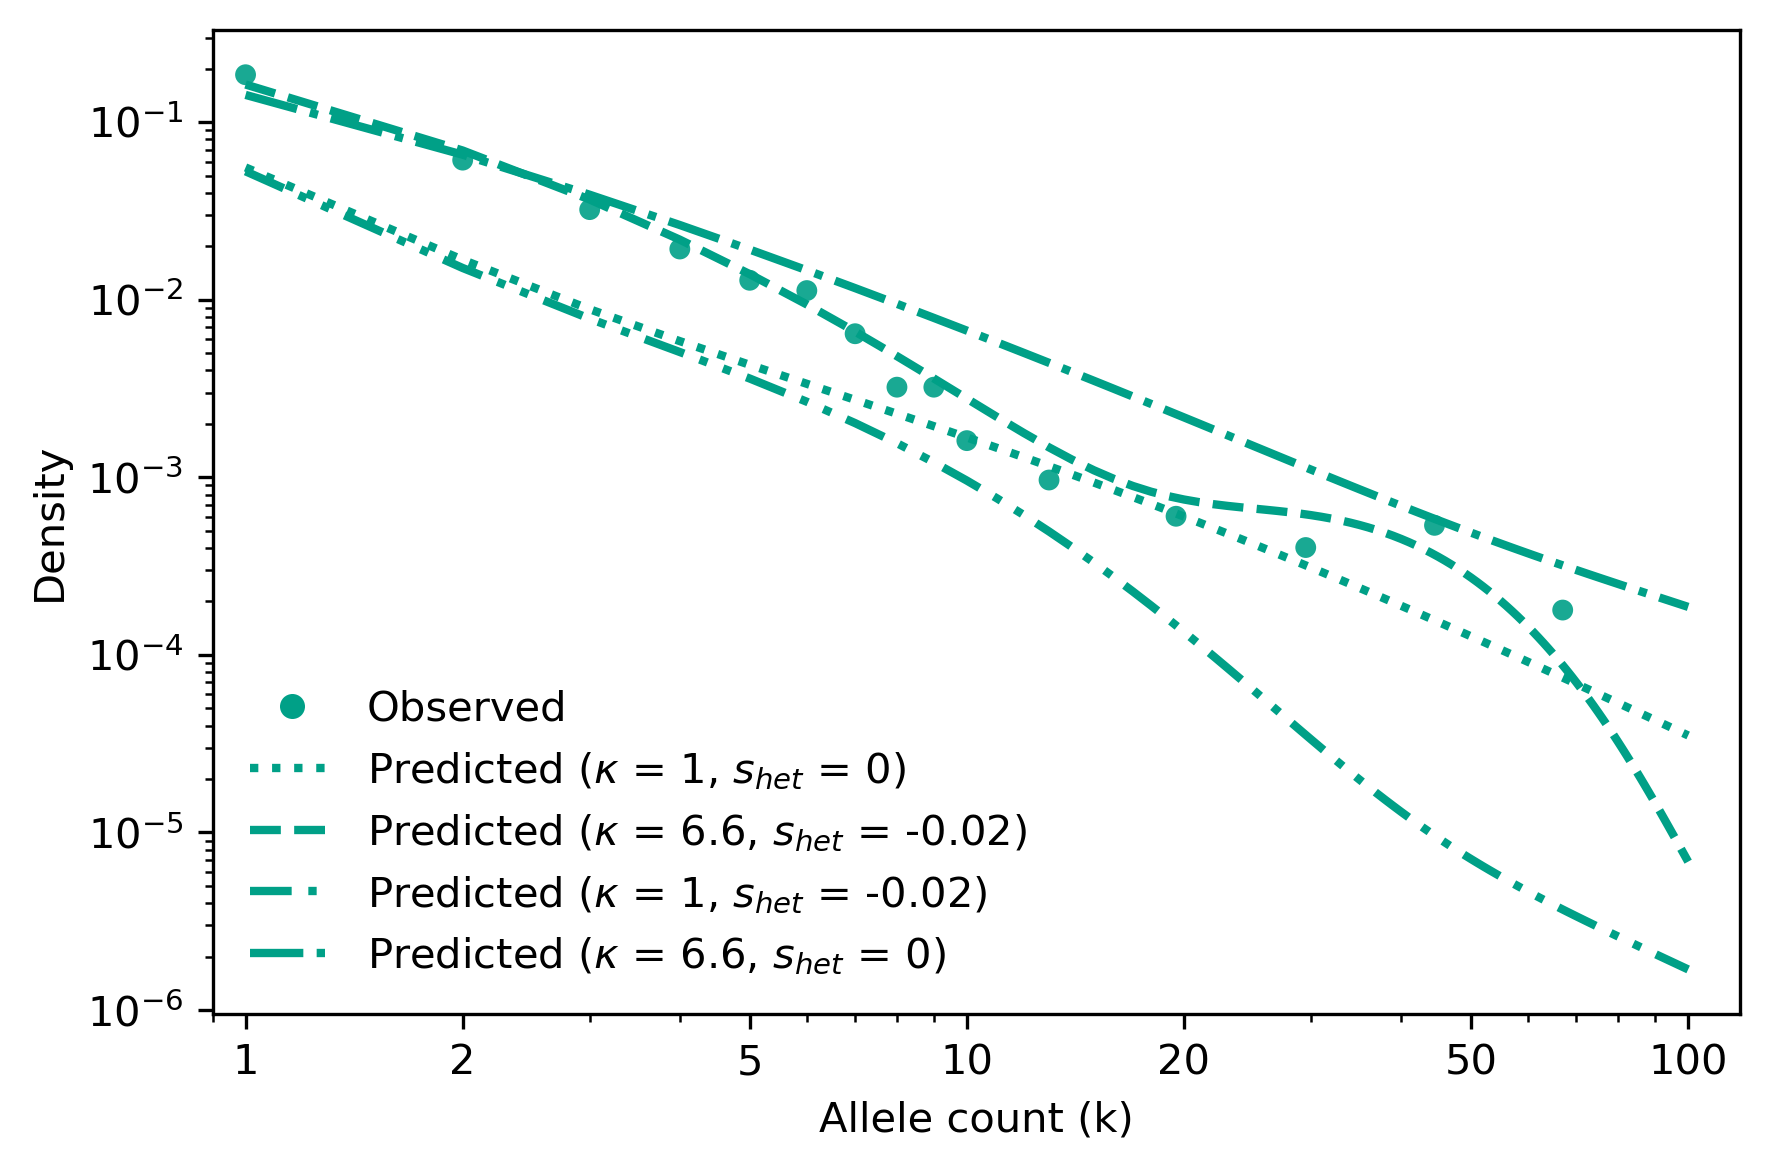

In [43]:
gene_ids_plot = ["ENSG00000101752"]
plot_sfs_CES_LoF_syn_genes(gene_ids_plot, gene_dfs_LoF, gene_dfs_syn, LL_sum_dict, kappa, s_values, demography, SFSs, pnull_dict, 
                               ac_col, AN_col, gene_size_dict_LoF, gene_size_dict_syn, kmax=100, jmin=10, bb=1.5, figsize=(6, 4), dpi = 300, outfile="../Figures/SFS_MIB1_supp.svg")

## Other codes

### Plot for misannotations

In [4]:
def observed_counts_from_ac(ac, nn_tot, jmin, bb, incl_zero = True):

    nn = np.ones_like(ac, dtype=float)         # each site counts once

    # Construct bins: unit bins up to 4, then geometric
    bins = plot_SFS.make_bins(jmin=jmin, bb=bb, nn=nn_tot, incl_zero = incl_zero)
    # Bin sizes (widths in allele-count units)
    widths = plot_SFS.bin_sizes(bins)
    # Raw totals per bin
    totals = plot_SFS.bin_data(ac, nn, bins)
    # Normalize to density: counts per allele-count unit
    density = totals / widths
    # Get bin midpoints
    means = plot_SFS.bin_means(bins)

    return means, density

def predicted_counts_gene_misannot(gene_df, SFSs, s_ind, pnull_dict, kmax=5000):
    """
    Predicted expected counts per exact allele count k, for one demography.
    SFSs shape assumed: (n_mu, n_s_plus_neut, kmax+1) with neutral at index -1.
    """
    pred = np.zeros(kmax+1, dtype=float)
    pred_mis = np.zeros(kmax+1, dtype=float)
    pred_sel = np.zeros(kmax+1, dtype=float)

    mu_inds = gene_df["MR_rank"].to_numpy(dtype=int)
    annots  = gene_df["most_severe_consequence2"].astype(str).to_numpy()

    for mu_i, annot in zip(mu_inds, annots):
        pnull = pnull_dict.get(annot, None)
        if pnull is None:
            continue
        pred += pnull * SFSs[mu_i, -1, :kmax+1] + (1 - pnull) * SFSs[mu_i, s_ind, :kmax+1]
        pred_mis += SFSs[mu_i, -1, :kmax+1]
        pred_sel += SFSs[mu_i, s_ind, :kmax+1]
        
    return pred, pred_mis, pred_sel

In [6]:
# Nature (ggsci::npg) color palette
color_cycle = [
    "#E64B35",  # red
    "#4DBBD5",  # blue
    "#00A087",  # green
    "#3C5488",  # navy
    "#F39B7F",  # orange
    "#8491B4",  # purple
    "#91D1C2",  # teal
    "#DC0000",  # dark red
]

def plot_sfs_misannot(gene_ids, gene_dfs, LL_sum_dict, s_values, demography, SFSs_demog, pnull_dict, ac_col, an_col, gene_size_dict, df_summary,
                                       kmax=100, jmin=4, bb=2.0, figsize=(6, 4), dpi = 300,  # good for 1-column-ish paper width; adjust as needed
                                       outfile=None):
    """
    Single plot overlaying multiple genes with different s_hat,
    showing Observed (points) and Predicted (dashed lines).
    """

    # --- pick 4 genes (closest to target s) ---
    chosen = gene_ids

    if len(chosen) == 0:
        raise ValueError("No genes could be chosen (check LL_sum_dict/s_values overlap).")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    gene_handles = []

    for idx, gene_id in enumerate(chosen):
        if gene_id not in gene_dfs or gene_id not in LL_sum_dict:
            continue

        df = gene_dfs[gene_id]
        if df is None or df.empty or ac_col not in df.columns or an_col not in df.columns:
            continue

        ac = df[ac_col].to_numpy()
        AN = df[an_col].mode().iloc[0]

        LL_vec = np.asarray(LL_sum_dict[gene_id], float)
        s_ind = int(np.argmax(LL_vec))
        s_hat = df_summary[df_summary["gene_id"] == gene_id]["Posterior_mean"].values[0]

        # Observed (binned) + Predicted (exact)
        mean_obs, obs_counts = observed_counts_from_ac(ac, AN, jmin, bb)
        pred_counts, pred_counts_mis, pred_counts_sel = predicted_counts_gene_misannot(df, SFSs_demog, s_ind, pnull_dict, kmax=kmax)

        total = gene_size_dict[gene_id]

        # ---- DROP k=0 ----
        m = np.asarray(mean_obs)
        obs_y = np.asarray(obs_counts, float) / total
        keep_obs = (m >= 1) & (m <= kmax) & np.isfinite(obs_y) & (obs_y > 0)
        m = m[keep_obs]
        obs_y = obs_y[keep_obs]

        kmax_new = m[-1] +5

        k = np.arange(len(pred_counts))
        pred_y = np.asarray(pred_counts, float) / total
        pred_y_mis = np.asarray(pred_counts_mis, float) / total
        pred_y_sel = np.asarray(pred_counts_sel, float) / total
        keep_pred = (k >= 1) & (k <= kmax_new) & np.isfinite(pred_y) & (pred_y > 0)
        k = k[keep_pred]
        pred_y = pred_y[keep_pred]
        pred_y_mis = pred_y_mis[keep_pred]
        pred_y_sel = pred_y_sel[keep_pred]

        c = color_cycle[idx % len(color_cycle)]

        # Observed = points, Predicted = dashed line
        ax.scatter(m, obs_y, s=18, alpha=0.9, edgecolors="none", color=c)
        ax.plot(k, pred_y, lw=2.0, ls="-", color=c)
        ax.plot(k, pred_y_mis, lw=2.0, ls="--", color=c)        
        ax.plot(k, pred_y_sel, lw=2.0, ls="-.", color=c)
        
        gene_handles.append(
            Line2D([0], [0], color=c, lw=2.2, label=rf"$s_{{\mathrm{{het}}}} = {s_hat:.1e}$")
        )

    # Axes styling (paper-friendly)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1-0.1, kmax_new+1)
    ax.set_xlabel("Allele count (k)")
    ax.set_ylabel("Density")

    ticks = [1, 2, 5, 10, 20, 50, 100]
    ticks = [t for t in ticks if t <= kmax_new]
    ax.set_xticks(ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.ticklabel_format(axis='x', style='plain')

    # Legends: gene colors + obs/pred style
    style_handles = [
        Line2D([0], [0], marker='o', color='k', lw=0, markersize=5, label="Observed"),
        Line2D([0], [0], color='k', lw=2.0, ls='-', label="Predicted"),
        Line2D([0], [0], color='k', lw=2.0, ls='--', label="Predicted (Misannotated)"),
        Line2D([0], [0], color='k', lw=2.0, ls='-.', label="Predicted (Selection)")
    ]

    leg1 = ax.legend(handles=gene_handles, loc="upper right", frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc="lower left", frameon=False)

    fig.tight_layout()
    if outfile:
        fig.savefig(outfile, bbox_inches="tight")


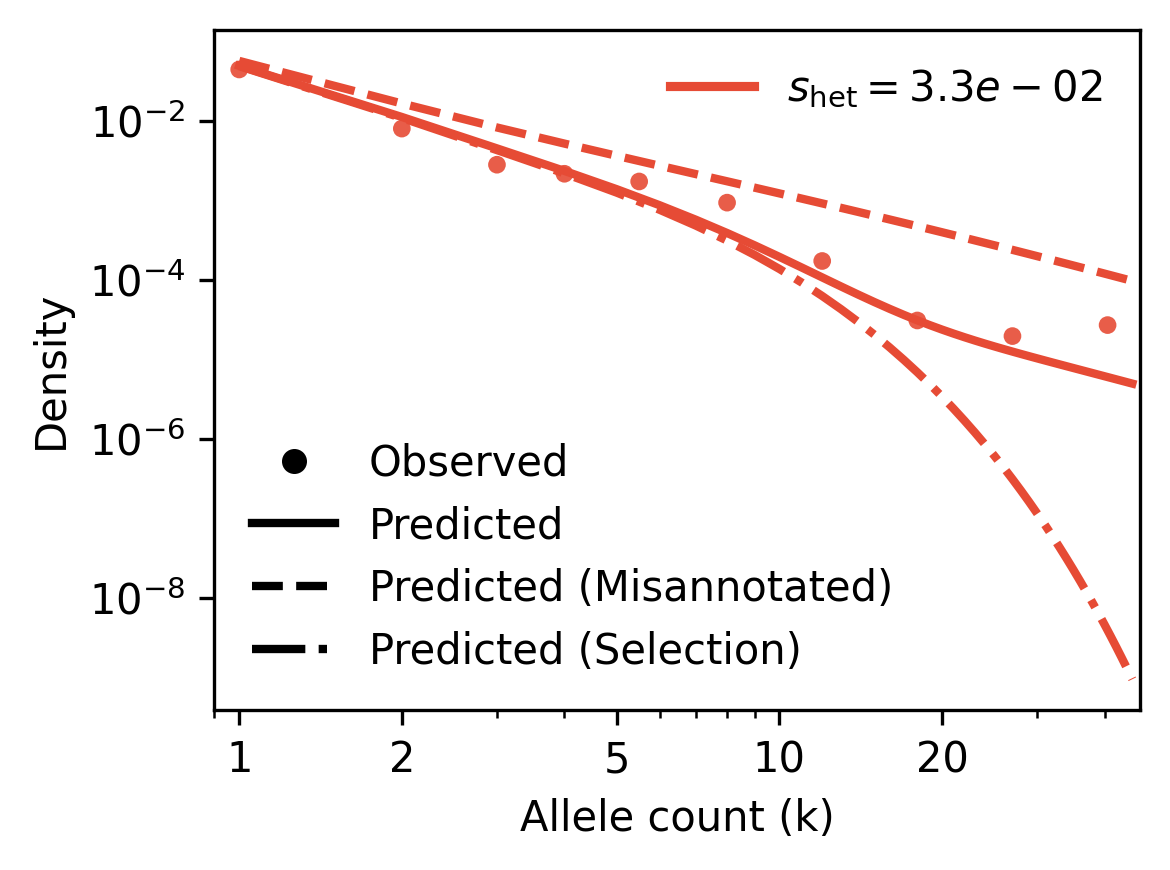

In [11]:
# 'ENSG00000127603', 'ENSG00000064687'
gene_ids_plot = ['ENSG00000054654']
plot_sfs_misannot(gene_ids_plot, gene_dfs, LL_sum_dict, s_values, demography, SFSs, pnull_dict, ac_col, AN_col, gene_size_dict, df_summary,
                  kmax=100, jmin=4, bb=1.5, figsize=(4, 3),  # good for 1-column-ish paper width; adjust as needed
                  outfile="../../../presentation_ASHG/figures/SFS_SYE2_misannot.svg")